<a href="https://colab.research.google.com/github/wisesprout/project1_vgames/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames2.csv', index_col = 0)
df.head()
df = df.dropna()  # na 값 있는 데이터 제외

# 1. preprocessing vgames2
1 - 1) Publisher 전처리

In [2]:
df['Publisher'].unique()
pd.set_option('display.max_rows', None)  # value_counts 모든 값
df['Publisher'].value_counts()  # 99개의 'Unknown' 값 확인
df[df['Publisher']=='Unknown']  # 결과를 조사해보니 'Unknown Wordls Entertainment'가 아님을 확인
df.drop(df[df['Publisher']=='Unknown'].index, inplace = True)
df[df['Publisher']=='Unknown']  # drop한 결과 확인

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales


1 - 2) Year 전처리

In [3]:
# Year 정리

# df['Year'] = df['Year'].astype(int) 이건 왜 안되고 밑줄은 되지???
df.Year = df.Year.astype(int)
# Year가 4자리 아니면 drop
i = 0
while i < len(df['Year']):
    digit = 0
    year = df.iloc[i,2]
    while(year > 0):  # 10으로 계속 나눠서 자릿수 확인
        digit += 1
        year //= 10
    if digit != 4:
        df.drop(df.index[i], inplace = True)
    else:
        i += 1

df['Year'].unique()  # drop한 결과 확인

array([2008, 2009, 2010, 2005, 2011, 2007, 2001, 2003, 2006, 2014, 2015,
       2002, 1997, 2013, 1996, 2004, 2000, 1984, 1998, 2016, 1985, 1999,
       1995, 1993, 2012, 1987, 1982, 1994, 1990, 1992, 1991, 1983, 1988,
       1981, 1989, 1986, 2017, 1980, 2020])

1 - 3) Sales 단위 10,000으로 통일

In [4]:
# 단위 10,000으로 통일
for j in range(5,9):
  # j번째 컬럼의 단위를 숫자로 변경
  for i in range(len(df.iloc[:,j])):
    if ('K' in df.iloc[i,j]):  # j번째 컬럼의 i번째 값이 K를 포함하면
      df.iloc[i,j] = float(df.iloc[i,j].replace('K',''))/10**3  # K 삭제, 10^3으로 나누기, str->float
    elif ('M' in df.iloc[i,j]):  # j번째 컬럼의 i번째 값이 M을 포함하면
      df.iloc[i,j] = float(df.iloc[i,j].replace('M',''))  # M 삭제, str->float
    else:
      df.iloc[i,j] = float(df.iloc[i,j])  # K, M 없는 값은 str->float
  df.iloc[:,j] = (df.iloc[:,j]*100).astype(int)  # j번째 컬럼 전체 float->int

df.to_excel('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames_a.xlsx', index = False)

In [5]:
# 나머지 feature 값 확인
df['Platform'].value_counts()
df['Genre'].value_counts()
df['Genre'].unique()

array(['Action', 'Adventure', 'Misc', 'Platform', 'Sports', 'Simulation',
       'Racing', 'Role-Playing', 'Puzzle', 'Strategy', 'Fighting',
       'Shooter'], dtype=object)

# 2. 지역에 따라 선호하는 장르가 다를까?

2 - 1) 장르별 판매량 데이터프레임 생성

In [24]:
# 전체 데이터에서 지역별 장르의 출고량 데이터 추출
df2 = df[['Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
# g_s = genre by sales
g_s = df2.groupby(by=['Genre']).sum()
g_s

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,85411,51158,15463,18346
Adventure,10092,6324,5137,1661
Fighting,21998,9962,8633,3607
Misc,39298,20682,10357,7236
Platform,44224,19914,12920,5108
Puzzle,12068,5014,5612,1236
Racing,35332,23293,5499,7588
Role-Playing,30557,17575,33471,5452
Shooter,57045,30702,3732,10075


In [8]:
'''# 추출한 데이터에서 상위 5순위 출력
# 시각화 결과 검토를 위한 참고용

df2_top = pd.DataFrame(index =, columns = ['Top1','Top2','Top3','Top4','Top5']).fillna(0)
for j in range(0,4):  # df2에서 지역별 장르 판매량 내림차순
    # region's top genre = rtg
    rtg = df2.iloc[j].sort_values(ascending = False)
    #print(j,'번째 지역',rtg.index)
    for i in range (0,5):
        # j번째 지역의 장르 순위대로 대입
         df2_top.iloc[j,i] = rtg.index[i]
    
df2_top'''

,Top1,Top2,Top3,Top4,Top5
NA_sum,Action,Sports,Shooter,Platform,Misc
EU_sum,Action,Sports,Shooter,Racing,Misc
JP_sum,Role-Playing,Action,Sports,Platform,Misc
Other_sum,Action,Sports,Shooter,Racing,Misc


In [26]:
# g_s_t = genre by sales, tidy
g_s_t = g_s.reset_index()
g_s_t = pd.melt(g_s_t, id_vars = ['Genre'], 
                        value_vars = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'],
                        var_name = 'Sale_Area',
                        value_name = 'Sale_Total')
g_s_t.head()

,Genre,Sale_Area,Sale_Total
0,Action,NA_Sales,85411
1,Adventure,NA_Sales,10092
2,Fighting,NA_Sales,21998
3,Misc,NA_Sales,39298
4,Platform,NA_Sales,44224


In [9]:
na_top = df2.loc['NA_sum', :].sort_values(ascending = False)
eu_top = df2.loc['EU_sum', :].sort_values(ascending = False)
jp_top = df2.loc['JP_sum', :].sort_values(ascending = False)
ot_top = df2.loc['Other_sum', :].sort_values(ascending = False)

2 - 2) Pie chart를 이용한 시각화

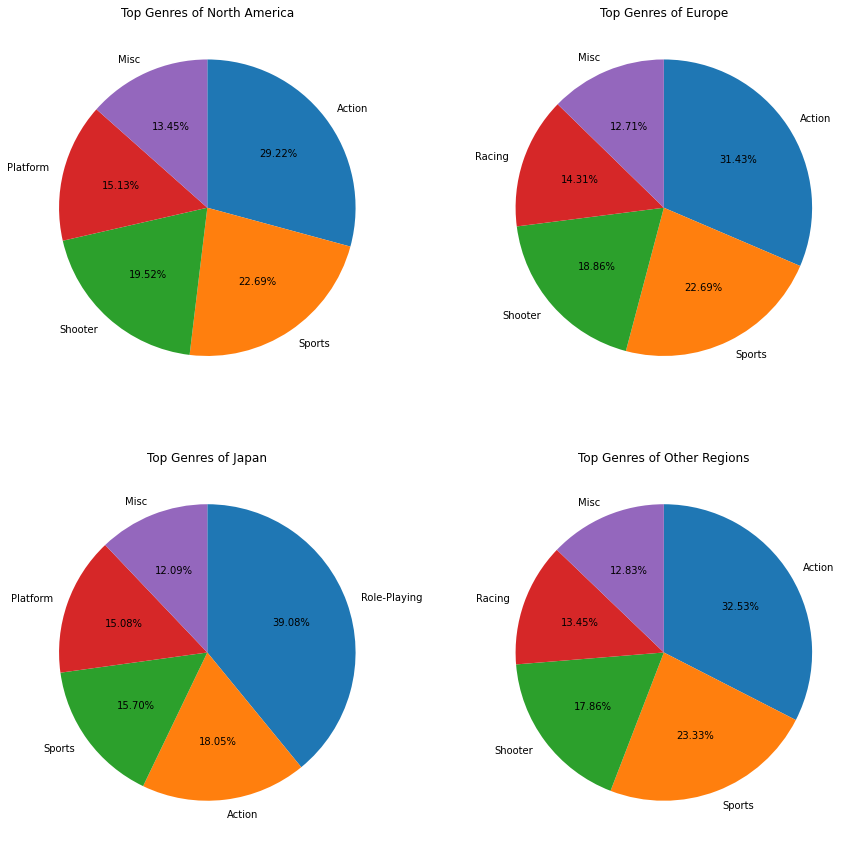

In [10]:
# 시각화 - pie chart
fig = plt.figure(figsize = (15,15))  # 배경
fig.set_facecolor('white')

# Top 5 Genres of NA_Sales
ax = plt.subplot(221)  # 기본 위치
ax.pie(x = na_top[0:5],  #  
       labels = na_top.index[0:5], 
       autopct = lambda x : '{:.2f}%'.format(x),
       startangle = 90,
       counterclock = False)
plt.title('Top Genres of North America')

# Top 5 Genres of EU_Sales
ax = plt.subplot(222)  # 기본 위치
ax.pie(x = eu_top[0:5], 
       labels = eu_top.index[0:5], 
       autopct = lambda x : '{:.2f}%'.format(x),
       startangle = 90,
       counterclock = False)
plt.title('Top Genres of Europe')

# Top 5 Genres of JP_Sales
ax = plt.subplot(223)  # 기본 위치
ax.pie(x = jp_top[0:5], 
       labels = jp_top.index[0:5], 
       autopct = lambda x : '{:.2f}%'.format(x),
       startangle = 90,
       counterclock = False)
plt.title('Top Genres of Japan')

# Top 5 Genres of Other_Sales
ax = plt.subplot(224)  # 기본 위치
ax.pie(x = ot_top[0:5], 
       labels = ot_top.index[0:5], 
       autopct = lambda x : '{:.2f}%'.format(x),
       startangle = 90,
       counterclock = False)
plt.title('Top Genres of Other Regions')
plt.show()

2 - 3) 지역별로 선호하는 장르가 다르다는 가설에 대한 검정

In [20]:
# kaggle 'sales comparison by genre'
df2 = df[['Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
genre_sales = df2.groupby(by=['Genre']).sum()
genre_sales

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,85411,51158,15463,18346
Adventure,10092,6324,5137,1661
Fighting,21998,9962,8633,3607
Misc,39298,20682,10357,7236
Platform,44224,19914,12920,5108
Puzzle,12068,5014,5612,1236
Racing,35332,23293,5499,7588
Role-Playing,30557,17575,33471,5452
Shooter,57045,30702,3732,10075


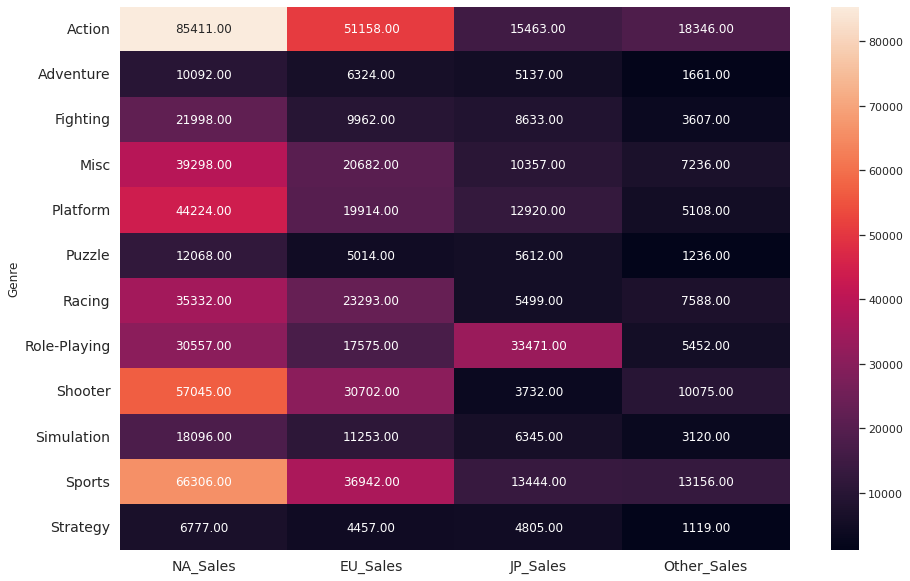

In [16]:
plt.figure(figsize=(15, 10))
sns.set(font_scale=1)
sns.heatmap(comp_map, annot=True, fmt = '.2f')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()